# EL-GHALI MOHAMED

# Régression Polynomiale avec PyTorch

Nous créons un modèle de régression polynomiale sur mesure en utilisant une classe `torch.nn.Module`.

In [11]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

## 1. Création du Dataset (Physique : Chute Libre)

Nous générons un jeu de données de 10 secondes. Les distances suivent une courbe non-linéaire

In [12]:
# données simulées : Temps (en secondes) vs Distance de chute (en mètres)
# Les valeurs suivent approximativement la formule physique
data_dict = {
    "Time_Seconds": [1,   2,   3,   4,   5,   6,   7,   8,   9,   10],
    "Distance_Meters": [5,  20,  44,  78, 122, 176, 240, 314, 397, 490]
}

# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)

# Création de nos tenseurs PyTorch directement depuis les valeurs brutes.
# Utilisation de torch.float32 qui est le standard optimisé pour les réseaux de neurones.
X = torch.tensor(data["Time_Seconds"].values, dtype=torch.float32)
Y = torch.tensor(data["Distance_Meters"].values, dtype=torch.float32)

## 2. Définition du Modèle Polynomial sur mesure

Nous utilisons l'orienté objet (`class`) de PyTorch pour reconstruire l'équation du polynôme.


In [13]:
# Définition de notre modèle de régression polynomiale
class polynomial_regression(torch.nn.Module):

    def __init__(self, degree):
        super().__init__()
        # On utilise nn.Parameter pour que PyTorch suive ces variables pour le gradient.
        self.coeffs = torch.nn.Parameter(torch.zeros(degree + 1, dtype=torch.float32))

    def forward(self, x):
        # La passe avant (forward) où on reconstruit manuellement l'équation :
        # y = c0*x^0 + c1*x^1 + ... + cn*x^n
        y = 0
        for i in range(len(self.coeffs)):
            y += self.coeffs[i] * (x ** i)
        return y

## 3. Entraînement

 L'élévation au carré de nos données (`X^2` peut valoir jusqu'à 100) nécessite un taux d'apprentissage très fin. Nous fixons `lr = 1e-5` et augmentons le nombre d'époques à 250.

In [14]:
# Instanciation du modèle avec un polynôme de degré 2 (quadratique)
degree = 2
model = polynomial_regression(degree=degree)

# Optimiseur gradient descents avec un taux d'apprentissage très faible
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5)
loss_fn = torch.nn.MSELoss()

losses = []
epochs = 250

print("Début de l'entraînement...\n")

for epoch in range(epochs):
    # 1: Calcul des prédictions
    y_pred = model(X)

    # 2: Évaluation de l'erreur (MSE)
    loss = loss_fn(y_pred, Y)

    # 3: Nettoyage, rétropropagation et mise à jour
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # Suivi de la perte pour observer la convergence
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:5} | Loss: {loss.item():.2f}")

Début de l'entraînement...

Epoch     0 | Loss: 60821.00
Epoch    50 | Loss: 311.88
Epoch   100 | Loss: 2.78
Epoch   150 | Loss: 1.20
Epoch   200 | Loss: 1.18
Epoch   249 | Loss: 1.18


## 4. Visualisation des performances du modèle


Coefficients trouvés par PyTorch :
c0 (pour X^0) = 0.0707
c1 (pour X^1) = 0.5692
c2 (pour X^2) = 4.8307


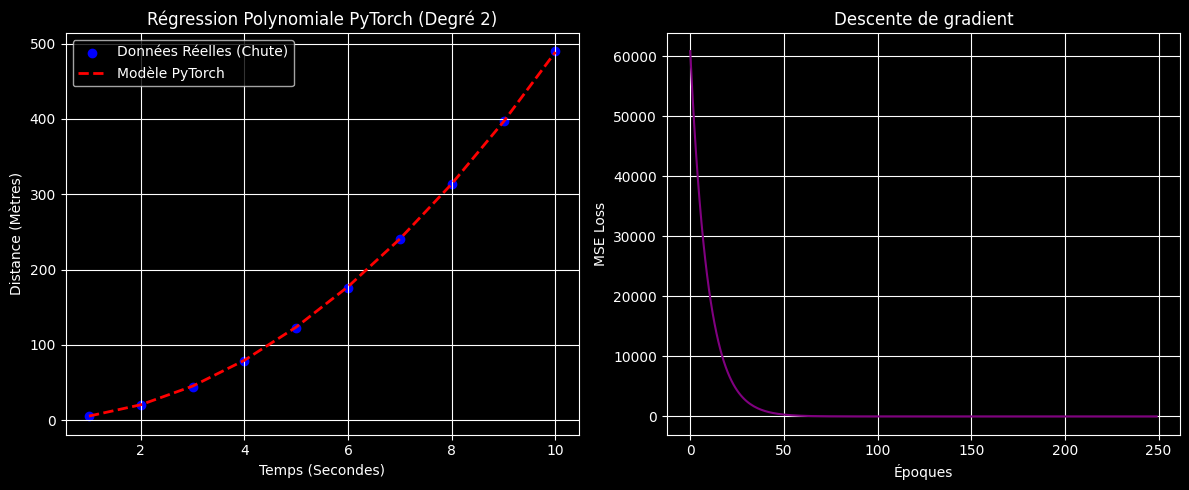

In [15]:
# --- Affichage des résultats ---
print("\nCoefficients trouvés par PyTorch :")
for i, coeff in enumerate(model.coeffs.detach().numpy()):
    print(f"c{i} (pour X^{i}) = {coeff:.4f}")

plt.figure(figsize=(12, 5))

# Graphique 1 : Modèle vs Données
plt.subplot(1, 2, 1)
plt.scatter(X.numpy(), Y.numpy(), color='blue', label="Données Réelles (Chute)")
# .detach().numpy() pour extraire les prédictions du graphe
plt.plot(X.numpy(), model(X).detach().numpy(), color="red", linestyle='--', linewidth=2, label="Modèle PyTorch")
plt.xlabel("Temps (Secondes)")
plt.ylabel("Distance (Mètres)")
plt.title(f"Régression Polynomiale PyTorch (Degré {degree})")
plt.legend()
plt.grid(True)

# Graphique 2 : Courbe de Perte
plt.subplot(1, 2, 2)
plt.plot(losses, color='purple')
plt.xlabel("Époques")
plt.ylabel("MSE Loss")
plt.title("Descente de gradient")
plt.grid(True)

plt.tight_layout()
plt.show()